In [1]:
#from https://www.quantstart.com/articles/brownian-motion-simulation-with-python/

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
rng = np.random.default_rng()
paths = 100
points = 1000
mean, std = 0, 1

In [4]:
Z = rng.normal(mean, std, (paths, points))

In [5]:
interval = [0, 1]
dt = (interval[1] - interval[0])/ (points-1)

In [6]:
tAxis = np.linspace(interval[0], interval[1], points)

In [7]:
W = np.zeros((paths, points))
for idx in range(points-1):
    real_idx = idx + 1
    W[:, real_idx] = W[:, real_idx -1] + np.sqrt(dt) * Z[:, idx]

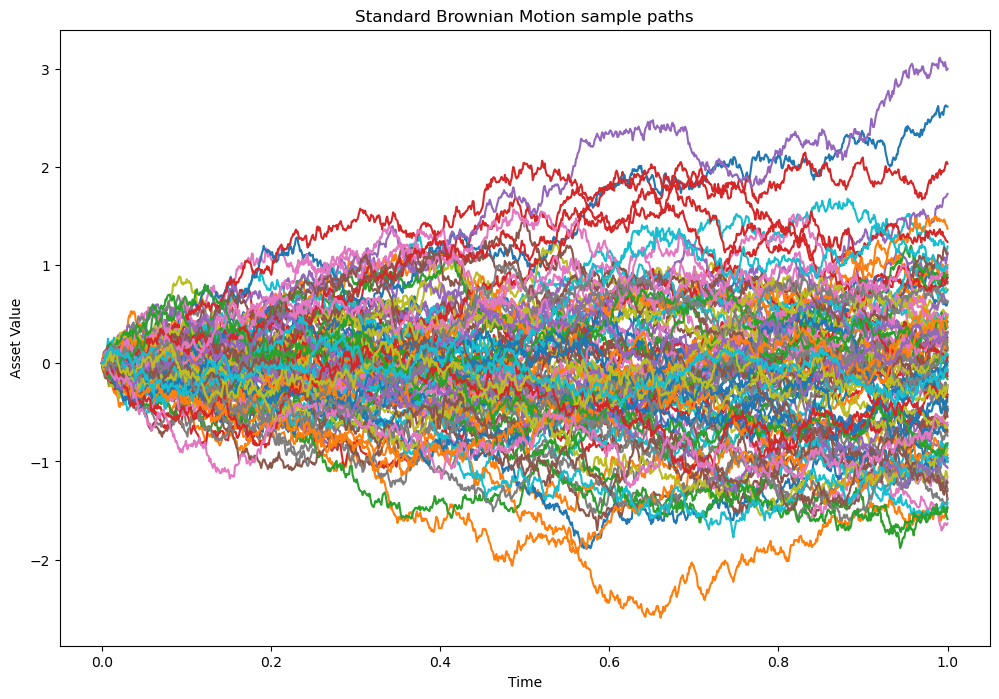

In [8]:
fig, ax = plt.subplots(1,1, figsize = (12,8))
for path in range(paths):
    ax.plot(tAxis, W[path, :])
ax.set_title("Standard Brownian Motion sample paths")
ax.set_xlabel("Time")
ax.set_ylabel("Asset Value")
plt.show()
                

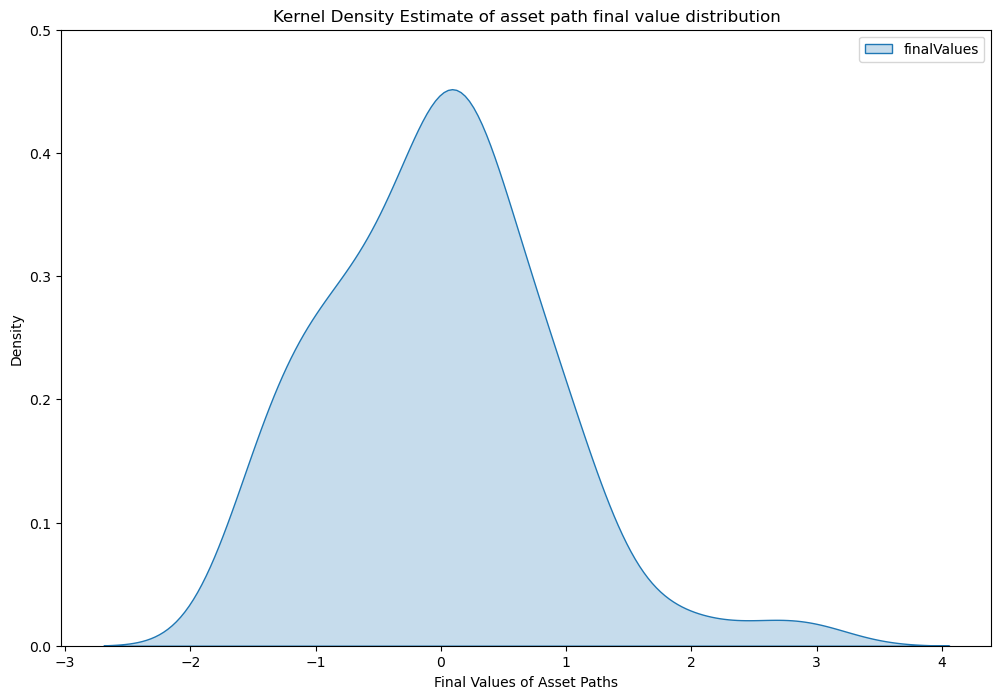

In [9]:
finalValues = pd.DataFrame({'finalValues': W[:, -1]})
fig, ax = plt.subplots(1,1, figsize = (12, 8))
sns.kdeplot(data=finalValues, fill=True, ax=ax)
ax.set_title("Kernel Density Estimate of asset path final value distribution")
ax.set_ylim(0.0, 0.5)
ax.set_xlabel('Final Values of Asset Paths')
plt.show()

In [10]:
print(finalValues.mean(), finalValues.std())

finalValues   -0.026479
dtype: float64 finalValues    0.88758
dtype: float64


In [11]:
muC, stdC = 5, 2

In [12]:
X = np.zeros((paths, points))
for idx in range(points - 1):
    real_idx = idx + 1
    X[:, real_idx] = X[:, real_idx - 1] + muC * dt + stdC * np.sqrt(dt) * Z[:, idx]

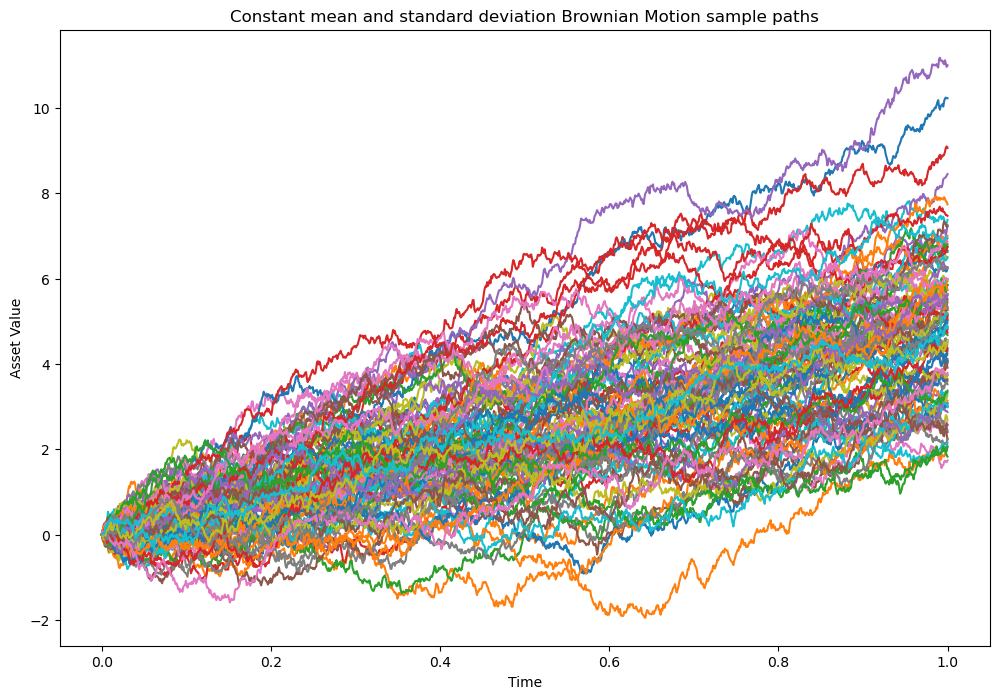

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
for path in range(paths):
    ax.plot(tAxis, X[path, :])
ax.set_title("Constant mean and standard deviation Brownian Motion sample paths")
ax.set_xlabel("Time")
ax.set_ylabel("Asset Value")
plt.show()

In [14]:
#Upgrading the above to geometric brownian motion

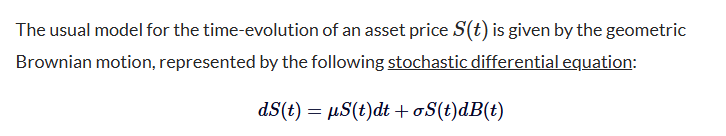

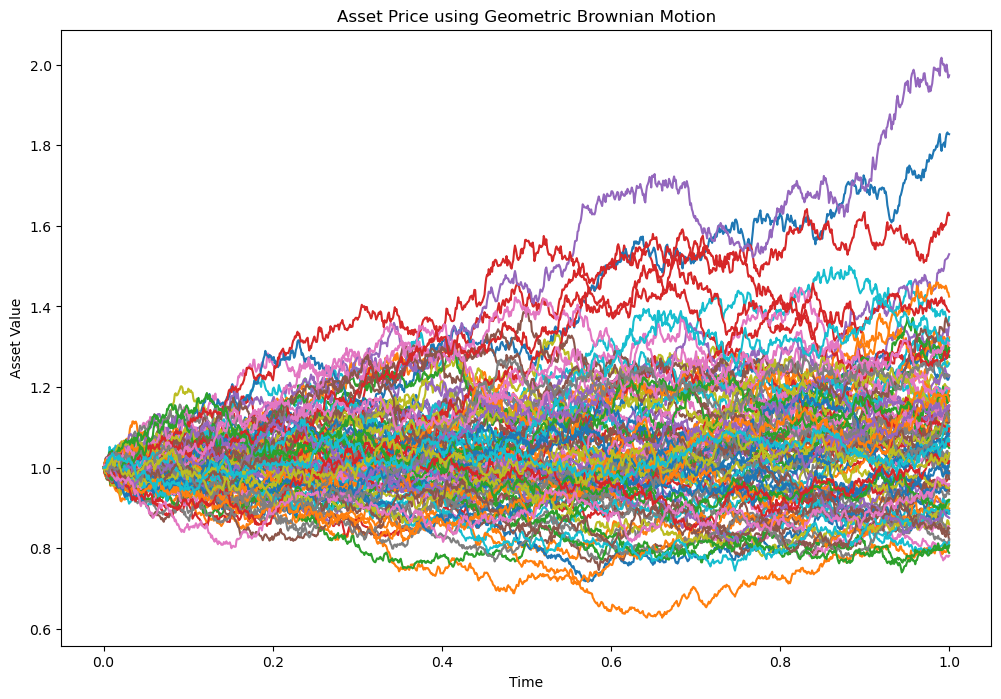

In [15]:
#assume starting asset price of $1
muC, stdC = .1, .2
X = np.zeros((paths, points))
for idx in range(points - 1):
    real_idx = idx + 1
    X[:, real_idx] = X[:, real_idx - 1] + muC * dt + stdC * np.sqrt(dt) * Z[:, idx]
s0 = 1
S = s0 * np.exp(X - (0.5 * stdC**2) * tAxis)
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
for path in range(paths):
    ax.plot(tAxis, S[path, :])
ax.set_title("Asset Price using Geometric Brownian Motion")
ax.set_xlabel("Time")
ax.set_ylabel("Asset Value")
plt.show()